# Dask DataFrame (2)

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Макрушин С.В. Лекция "Dask DataFrame"
* https://docs.dask.org/en/latest/dataframe.html
* Jesse C. Daniel. Data Science with Python and Dask. 

* https://docs.dask.org/en/stable/generated/dask.dataframe.groupby.DataFrameGroupBy.apply.html
* https://docs.dask.org/en/stable/generated/dask.dataframe.Series.map_overlap.html#dask.dataframe.Series.map_overlap
* https://docs.dask.org/en/stable/_modules/dask/dataframe/rolling.html#Rolling.apply
* https://dask-sql.readthedocs.io/en/latest/quickstart.html

In [42]:
import dask.dataframe as dd
import dask.bag as db
import dask_sql as ds
from dask_sql import Context
import matplotlib.pyplot as plt
import seaborn as sns

## Задачи для совместного разбора

1. Загрузите данные о пользователях из архива каталога users. Посчитайте средний возраст каждого представленного пола.

In [2]:
ddf = dd.read_csv('./data/users/*.csv')
ddf.head()

,id,name,age,gender
0,0,GBWAKSZR,57,female
1,1,JZFLVFWE,71,female
2,2,FVKATMOC,65,female
3,3,IIJOOMKY,70,male
4,4,IEBIJZHJ,76,male


In [3]:
ddf.groupby("gender")["age"].mean().compute()

gender
female    48.303251
male      48.155142
Name: age, dtype: float64

2. Создайте bag на основе данных из файла users.txt. Преобразуйте его в dataframe и объедините с фреймом из задачи 1. 


In [4]:
def f(row):
    kv: list = row.rstrip().split()
    r = dict(map(lambda x: x.split(":"), kv))
    r["uid"] = int(r["uid"])
    return r

In [5]:
bag = db.read_text("data/users.txt").map(f)
bag.take(1)

({'uid': 0,
  'street_number': '253',
  'street_name': 'smalfbhbmq',
  'city': 'druxufva',
  'state': 'QU',
  'zip_code': '12277'},)

In [6]:
ddf2 = bag.to_dataframe()
ddf2

,uid,street_number,street_name,city,state,zip_code
npartitions=1,,,,,,
,int64,object,object,object,object,object
,...,...,...,...,...,...


In [7]:
ddf.merge(ddf2, left_on="id", right_on="uid").compute()

,id,name,age,gender,uid,street_number,street_name,city,state,zip_code
0,0,GBWAKSZR,57,female,0,253,smalfbhbmq,druxufva,QU,12277
1,1,JZFLVFWE,71,female,1,591,xduktcwwbn,rnbfaehq,KT,44340
2,2,FVKATMOC,65,female,2,660,omggxsgdnb,rchrmqzu,SE,80696
3,3,IIJOOMKY,70,male,3,810,jmpllqdjmy,boujamgy,QR,45706
4,4,IEBIJZHJ,76,male,4,344,iwzdcewpnq,rjjuktgk,QO,78134
...,...,...,...,...,...,...,...,...,...,...
2495,7495,XMRQKBAI,64,female,7495,422,dosxmwawou,uvhlvvhm,EW,36184
2496,7496,AWLJMQIM,49,male,7496,827,cfmvfiyupv,fymlldfv,YF,57459
2497,7497,DJWURQRZ,27,female,7497,966,lssxrurjkm,poojlccp,EI,76843
2498,7498,VSSFUJBH,74,male,7498,419,ssposhqgjy,vizmibrg,CP,43850


3. Вычислите произведение каждой пары последовательно идущих возрастов людей.

In [8]:
ddf["age"].head()

0    57
1    71
2    65
3    70
4    76
Name: age, dtype: int64

In [9]:
ddf["age"].rolling(window=2).mean().head()

0     NaN
1    64.0
2    68.0
3    67.5
4    73.0
Name: age, dtype: float64

In [10]:
def product(s):
    return s.prod()

ddf["age"].rolling(window=2).apply(product, raw=False).head()

0       NaN
1    4047.0
2    4615.0
3    4550.0
4    5320.0
Name: age, dtype: float64

4. Используя dask_sql, найдите топ-5 возрастов, имеющих наибольшее кол-во представителей.

In [11]:
ddf = dd.read_csv('data/users/*.csv')
ddf.head()

,id,name,age,gender
0,0,GBWAKSZR,57,female
1,1,JZFLVFWE,71,female
2,2,FVKATMOC,65,female
3,3,IIJOOMKY,70,male
4,4,IEBIJZHJ,76,male


In [12]:
c = Context()
c.create_table("users", ddf)
c.sql('''
SELECT age, COUNT(*) AS something
FROM users
GROUP BY age
ORDER BY something DESC
LIMIT 5
''').compute()

,age,something
28,55,192
24,42,186
17,25,180
2,65,180
44,38,179


5. Создайте функцию rename_gender и сделайте выборку из таблицы с ее использованием при помощи dask_sql

In [13]:
def rename_gender(genders):
    return genders.map({"female": "девочки", "male": "мальчики"})

c.register_function(
    rename_gender,
    "ren",
    [("genders", str)], # аргументы и их тип
    str # тип возвращаемого значения
)

c.sql('''
SELECT *, ren(gender)
FROM users
''').compute()

,id,name,age,gender,ren(users.gender)
0,0,GBWAKSZR,57,female,девочки
1,1,JZFLVFWE,71,female,девочки
2,2,FVKATMOC,65,female,девочки
3,3,IIJOOMKY,70,male,мальчики
4,4,IEBIJZHJ,76,male,мальчики
...,...,...,...,...,...
2495,9995,SYWAEVDP,46,female,девочки
2496,9996,KRDSBXUZ,79,female,девочки
2497,9997,BTNYEWOP,32,male,мальчики
2498,9998,HOUELSOM,44,female,девочки


## Лабораторная работа 13

__При решении данных задач не подразумевается использования циклов или генераторов Python в ходе работы с пакетами `numpy`, `pandas` и `dask`, если в задании не сказано обратного. Решения задач, в которых для обработки массивов `numpy`, структур `pandas` или структур `dask` используются явные циклы (без согласования с преподавателем), могут быть признаны некорректными и не засчитаны.__

В ходе выполнения все операции вычислений проводятся над `dask.DataFrame` и средствами пакета `dask`, если в задании не сказано обратного. Переход от коллекций `dask` возможен исключительно для демонстрации результата в конце решения задачи. Если в задаче используются результаты выполнения предыдущих задач, то подразумевается, что вы используете результаты в виде `dask.DataFrame` (то есть то, что было получено до вызова `compute`, а не после).

<p class="task" id="1"></p>

1\. В архиве `recipes_full.zip` находятся файлы, содержащие информацию об рецептах блюд. Загрузите данные из файлов этого архива в виде `dd.DataFrame` с названием `recipes`. Для каждого автора рассчитайте максимальное количество ингредиентов, которые используются в его рецептах.

In [14]:
recipes = dd.read_csv('data/recipes_full/recipes_full_*.csv', dtype={'minutes': 'float64', 'n_steps': 'float64'})
recipes['submitted'] = dd.to_datetime(recipes['submitted'])
recipes.groupby(by='contributor_id')['n_ingredients'].max().compute()

contributor_id
27            10
1530          15
1531          13
1533          25
1534          20
              ..
2000111609     9
211616         8
254715         8
438612         7
795406        16
Name: n_ingredients, Length: 27926, dtype: int64

<p class="task" id="2"></p>

2\. Удалите строки, которые содержат пропуске в столбце `contributor_id` и приведите его тип к целочисленному. Для каждого `contributor_id` найдите топ-5 слов, которых этот пользователь наиболее часто использовал в названиях своих рецептов. Для разбиения на слова воспользуйтесь методом `.str.split`.

Выведите на экран статистику для пользователя с ID 1530.

In [15]:
recipes.dropna(subset=['contributor_id'])
recipes['contributor_id'] = recipes['contributor_id'].astype(int)

print(f"Кол-во пропусков в столбце 'contributor_id': {dd.isna(recipes['contributor_id']).sum().compute()}")
print(f'Тип данных столбца "contributor_id": {recipes["contributor_id"].dtype}')


Кол-во пропусков в столбце 'contributor_id': 0
Тип данных столбца "contributor_id": int64


In [16]:
import copy
recipes_copy = copy.deepcopy(recipes)
recipes_copy['splited_name'] = recipes_copy['name'].str.split()
recipes_copy.head()

,id,name,minutes,contributor_id,submitted,n_steps,description,n_ingredients,splited_name
0,683970,vant ivoire mickies nothing,33.0,803776,2019-08-22,4.0,pat and gina neely and their family own and op...,9,"[vant, ivoire, mickies, nothing]"
1,1089012,kremsils mariposa baccala cookies class borage...,23.0,51579,2013-03-02,1.0,"a light, tasty and easy to put together chicke...",5,"[kremsils, mariposa, baccala, cookies, class, ..."
2,1428572,tania lander,0.0,68884,1980-11-09,1.0,a delicious melt in your mouth appetizer. for ...,5,"[tania, lander]"
3,1400250,heloise milli asher doogh zojirushi,24.0,678862,2018-04-29,3.0,delicious cream cheese and peach filled cresce...,1,"[heloise, milli, asher, doogh, zojirushi]"
4,387709,nutty chocolate chunk cookies,47.0,489552,2009-08-31,8.0,everyone loves these buttery cookies chock ful...,10,"[nutty, chocolate, chunk, cookies]"


In [17]:
from collections import Counter

most_common_words = recipes_copy.groupby(by='contributor_id')['splited_name'].sum()
most_common_words = most_common_words.apply(lambda x: Counter(x).most_common(5)).compute()
most_common_words[1530]

/home/olclrx/.local/lib/python3.10/site-packages/dask/dataframe/core.py:4341: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, meta=('splited_name', 'object'))

  warnings.warn(meta_warning(meta))


[('chocolate', 7), ('muffins', 6), ('bread', 5), ('and', 4), ('whole', 3)]

<p class="task" id="3"></p>

3\. В архиве `stats.zip` находятся файлы, содержащие статистику по рецептам. Загрузите данные из файлов этого архива в виде `dd.DataFrame` с названием `stats`. Объедините две таблицы `recipes` и `stats`. Для каждого рецепта посчитайте среднее количество лайков за период, начиная с даты публикации рецепта и до 1 апреля 2023 года (включительно). Выведите на экран информацию о рецепте, имеющем максимальное значение этой величины.

In [18]:
stats = dd.read_csv('data/stats/stats_*.csv')
recipes['id'] = recipes['id'].astype(str)
df_merge = recipes.merge(stats, left_on='id', right_on='recipe_id')
df_merge = df_merge.drop(['recipe_id'], axis=1)
df_merge.head()

,id,name,minutes,contributor_id,submitted,n_steps,description,n_ingredients,views,likes,verified
0,1798295,texans pierogie aelplermagronen jonghe bom hen...,29.0,50474,1993-11-04,1.0,from: campbell's kitchensavory italian sausage...,5,1633,437,False
1,301780,paparot seacoast snacker ginisang,57.0,286566,2011-08-11,5.0,a nice holiday candy treat. combines the holid...,6,2128,7425,False
2,2071147,xxx ilene bobota clothes,3.0,64153,2005-01-04,1.0,great for mardi gras entertaining - got it fro...,1,6556,3234,False
3,682462,gentlemen judys knysh rim highlight clumps res...,11.0,64642,1993-01-21,4.0,"delicious, creamy soup that's great on a cold ...",6,4353,9629,False
4,804317,tahitian hunk garlic staples,51.0,481092,2015-03-13,1.0,this recipe was found on www.recipes.wuzzle.or...,7,2039,598,False


In [19]:
from datetime import datetime

df_merge['mean_likes'] = df_merge['likes'] / (datetime(2023, 4, 2) - df_merge['submitted']).dt.days
df_merge.head()


,id,name,minutes,contributor_id,submitted,n_steps,description,n_ingredients,views,likes,verified,mean_likes
0,87145,chocolate chunk croissant bread pudding,60.0,52543,2004-03-21,18.0,individual dishes that are great for,8,7705,6927,True,0.996547
1,87145,chocolate chunk croissant bread pudding,60.0,52543,2004-03-21,18.0,individual dishes that are great for,8,4168,7721,False,1.110775
2,1337133,poly alsacienne paws romanov tamatiebredie,12.0,68357,2005-05-21,6.0,putting here for safe keeping to use with my d...,6,3872,7242,False,1.109885
3,1704479,b53,46.0,5060,2014-12-19,1.0,i got this recipe from a co-worker who made it...,7,8662,8058,True,2.662921
4,907319,tlalpeo cassoulet quich krem quacamole contine...,49.0,208121,1975-04-18,6.0,men's health,4,3267,8033,False,0.458609


In [20]:
df_merge[df_merge['mean_likes'] == df_merge['mean_likes'].max()].compute()

,id,name,minutes,contributor_id,submitted,n_steps,description,n_ingredients,views,likes,verified,mean_likes
144138,1552249,huckleberry boggles patatesli cereveja doogh,40.0,689540,2021-08-08,6.0,"i got this recipe from my sister, who got it f...",6,9241,9971,True,16.563123


<p class="task" id="4"></p>

4\. Используя `dask_sql`, выберите из таблицы `recipes` id, название и описание тех рецептов, которые были добавлены в 2010 году. Выведите полученный результат на экран в виде `pd.DataFrame`. Выведите на экран количество  рецептов, которые были добавлены в 2010 году.

In [21]:
c = Context()
c.create_table('recipes', recipes)
df_recipes_from_2010 = c.sql('''
SELECT id, name, description
FROM recipes
WHERE SUBSTRING(submitted, 1, 4) = '2010'
''').compute()
df_recipes_from_2010.head()

,id,name,description
8,818815,beirox dalmation gittle rougeux,my father is from iran and this is the way he ...
379,380095,shabbos sourest includes chevops schelvisch en...,"i have made several different chili recipes, a..."
381,1006702,stitch frisch roses oranged levana,"spinach, blueberries, and blue cheese in a ras..."
388,1519209,gingernuts anconetana reuben,this recipe is a take on my recipe #459346 usi...
407,438167,deep chocolate pistachio brownies,found in family circle. these have such a nic...


In [22]:
# количество рецептов
df_recipes_from_2010.shape[0]

50839

<p class="task" id="5"></p>

5\. Создайте функцию `get_recipe_types`, которая определяет сложность рецепта по следующему правилу: если кол-во ингредиентов не больше 5, то рецепт простой ("easy"); если не кол-во ингредиентов не больше 15, то рецепт средней сложности ("medium"); иначе рецепт является сложным ("hard"). 

```python
def get_type(ingredients: int) -> str:
    pass
```

Зарегистрируйте эту функцию для применения в SQL-запросе.

In [23]:
def get_type(ingredients: int) -> str:
    if ingredients <= 5:
        return 'easy'
    elif ingredients <= 15:
        return 'medium'
    else:
        return 'hard'

In [24]:
c.register_function(
    get_type,
    'get_type',
    [('ingredients', int)],
    str,
    replace=True
)

<p class="task" id="6"></p>

6\. Используя `dask_sql`, посчитайте количество рецептов с группировкой по их типу (простой, средний или сложный). Для определения типа рецепта в SQL-запросе воспользуйтесь функцией, зарегистрированной в предыдущем задании. Выведите на экран в виде серии с индексами "easy", "medium" и "hard". 

In [25]:
def get_type_func(data):
    return data.map(get_type)

c.register_function(
    get_type_func,
    'get_type_func',
    [('ingredients', int)],
    str, 
    replace=True
)

In [26]:
c.create_table('recipes', recipes, replace = True)
c.sql('''
CREATE OR REPLACE TABLE recipes_types AS (
SELECT get_type_func(n_ingredients) as types
FROM recipes
)
''')
c.sql('''
SELECT COUNT(types) as count, types
FROM recipes_types
GROUP BY types
''').head()

,count,types
0,1067731,medium
1,1151285,easy
2,12621,hard


<p class="task" id="7"></p>

7\. Используя `dask_sql`, объедините таблицы и посчитайте и выведите на экран, сколько рецептов являются верифицированными и не верифицированными. Если информация о верификации рецепта отсутствует, то считайте его не верифицированным. Вся логика подсчета значений должна быть реализована в виде запроса на языке SQL.

In [28]:
c.create_table('recipes', recipes, replace=True)
c.create_table('stats', stats, replace=True)

c.sql('''
CREATE OR REPLACE TABLE merge_recipes_stats AS (
SELECT *
FROM recipes LEFT OUTER JOIN stats
ON recipes.id = stats.recipe_id
)
''')

In [29]:
c.sql('''
SELECT COUNT(verified) as count, verified
FROM merge_recipes_stats
GROUP BY verified
''').compute()

,count,verified
0,0,NaN
1,1200065,False
2,443936,True


<p class="task" id="8"></p>

8\. В файлах архива `site_logs.zip` находятся логи системы. Считайте эти логи в виде `dask.bag`, выделите их них дату, время, id службы, уровень лога и сообщение. Объедините дату и время в одну строку в формате "ГГГГММДД ЧЧММСС". В итоге каждый элемент `Bag` должен представлять собой словарь с ключами `datetime`, `service_id`, `msg`, `level`.

Преобразуйте `dask.bag` в `dask.dataframe`, предварительно оставив только логи уровня "INFO". Подтвердите корректность решения, выведя на экран уникальные значения столбца `level` полученной таблицы.

```
date(ymd)   time(HMS)   service_id level   msg
081110      103041      34         INFO    dfs.FSNamesystem: BLOCK* NameSystem.delete: ...
```

In [30]:
site_logs = db.read_text('data/site_logs/logs_*')

In [35]:
def spliting(line):
    elements = line.strip().split(maxsplit=4)
    date = ' '.join(['20' + elements[0], elements[1]])
    service_id = elements[2]
    lvl = elements[3]
    msg = elements[4]
    return dict(zip(['date', 'service_id', 'level', 'msg'], [date, service_id, lvl, msg]))

dicts = site_logs.map(spliting).filter(lambda x: x['level'] == 'INFO')
df_logs = dicts.to_dataframe()
df_logs.head()

,date,service_id,level,msg
0,20081109 203518,143,INFO,dfs.DataNode$DataXceiver: Receiving block blk_...
1,20081109 203518,35,INFO,dfs.FSNamesystem: BLOCK* NameSystem.allocateBl...
2,20081109 203519,143,INFO,dfs.DataNode$DataXceiver: Receiving block blk_...
3,20081109 203519,145,INFO,dfs.DataNode$DataXceiver: Receiving block blk_...
4,20081109 203519,145,INFO,dfs.DataNode$PacketResponder: PacketResponder ...


In [36]:
df_logs['level'].unique().compute()

0    INFO
Name: level, dtype: object

<p class="task" id="9"></p>

9\. Добавьте в таблицу из предыдущего задания столбец `is_delete_op`, который содержит флаг: является ли данная операция удалением чего-либо или нет. Для выяснения этого факта проанализизируйте сообщение лога. 

Для каждого лога подсчитайте, сколько из записанных перед ним последних 100 логов являются операциями удаления. Для вычислений используйте метод `map_overlap`. Посчитайте и выведите на экран, сколько существует подпоследовательностей длины 100, состоящих не менее чем из 75 сообщений, содержащих операции удаления.

In [37]:
df_logs['is_delete_op'] = df_logs['msg'].apply(lambda x: 'delete' in x)
df_logs.head()

/home/olclrx/.local/lib/python3.10/site-packages/dask/dataframe/core.py:4341: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, meta=('msg', 'bool'))

  warnings.warn(meta_warning(meta))


,date,service_id,level,msg,is_delete_op
0,20081109 203518,143,INFO,dfs.DataNode$DataXceiver: Receiving block blk_...,False
1,20081109 203518,35,INFO,dfs.FSNamesystem: BLOCK* NameSystem.allocateBl...,False
2,20081109 203519,143,INFO,dfs.DataNode$DataXceiver: Receiving block blk_...,False
3,20081109 203519,145,INFO,dfs.DataNode$DataXceiver: Receiving block blk_...,False
4,20081109 203519,145,INFO,dfs.DataNode$PacketResponder: PacketResponder ...,False


In [39]:
df_logs['dels_before'] = df_logs['is_delete_op'].map_overlap(lambda x: x.rolling(window=100).sum(), before = 100, after = 0)
df_logs.head()

,date,service_id,level,msg,is_delete_op,dels_before
0,20081109 203518,143,INFO,dfs.DataNode$DataXceiver: Receiving block blk_...,False,NaN
1,20081109 203518,35,INFO,dfs.FSNamesystem: BLOCK* NameSystem.allocateBl...,False,NaN
2,20081109 203519,143,INFO,dfs.DataNode$DataXceiver: Receiving block blk_...,False,NaN
3,20081109 203519,145,INFO,dfs.DataNode$DataXceiver: Receiving block blk_...,False,NaN
4,20081109 203519,145,INFO,dfs.DataNode$PacketResponder: PacketResponder ...,False,NaN


In [40]:
# количество подпоследовательностей длины 100, состоящих не менее чем из 75 сообщений, содержащих операции удаления
(df_logs['dels_before'] >= 75).sum().compute()

1384848

<p class="task" id="10"></p>

10\. Сгруппируйте таблицу с логами по часу, в котором был оставлен лог. Под часом имеется в виду час конкретного дня, то связь связка год-месяц-день-час.  Посчитайте, сколько логов было записано за каждый час. Визуализируйте полученную динамику. Добавьте подписи засечек, подписи осей и название рисунка.

In [43]:
df_logs['date_hour'] = df_logs['date'].str[0:11]
visualization = df_logs.groupby(by='date_hour').count().compute()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


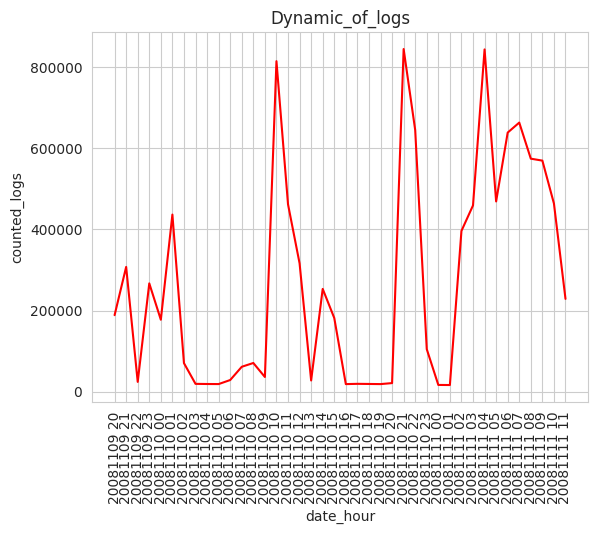

In [48]:
sns.set_style('whitegrid')
plt.plot(visualization.index, visualization['service_id'], color = 'red')
plt.xticks(rotation=90)
plt.xlabel('date_hour')
plt.ylabel('counted_logs')
plt.title('Dynamic_of_logs')
plt.show()